In [1]:
# Multilayer Perceptron
import pandas as pd
import numpy
# fix random seed for reproducibility
seed = 7
numpy.random.seed(seed)
import tensorflow as tf



import tensorflow.keras
import math
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2DTranspose,Input, Reshape, Conv2D, Flatten, Activation, LeakyReLU
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_squared_error
from tensorflow.keras.layers import concatenate, BatchNormalization
import argparse
#from tensorflow.keras.utils.np_utils import to_categorical
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Dropout
import numpy as np
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold
from scipy.stats import pearsonr, spearmanr
from skimage import io

In [2]:
####################
####### Functions #############
####################

def custom_loss_2 (y_true, y_pred):
    A = tensorflow.keras.losses.mean_absolute_error(y_true, y_pred)
    #B = keras.losses.categorical_crossentropy(y_true[:,-4:], y_pred[:,-4:])
    return A





def lrelu(x): #from pix2pix code
    a=0.2
    # adding these together creates the leak part and linear part
    # then cancels them out by subtracting/adding an absolute value term
    # leak: a*x/2 - a*abs(x)/2
    # linear: x/2 + abs(x)/2

    # this block looks like it has 2 inputs on the graph unless we do this
    x = tf.identity(x)
    return (0.5 * (1 + a)) * x + (0.5 * (1 - a)) * tf.abs(x)

def lrelu_output_shape(input_shape):
    shape = list(input_shape)
    return tuple(shape)

from tensorflow.keras.layers import Lambda
layer_lrelu=Lambda(lrelu, output_shape=lrelu_output_shape, name='Leaky_ReLU')


def createOutputLabels(Labels):
    output=np.zeros(shape=(len(Labels),12))    
    
    for i in range(len(Labels)):
        for j in range (4):
            if Labels.iloc[i,j]=='CN':
                output[i,j*3]=1
                output[i,j*3+1]=0
                output[i,j*3+2]=0

                
            elif Labels.iloc[i,j]=='MCI':
                output[i,j*3]=0
                output[i,j*3+1]=1
                output[i,j*3+2]=0
                
            elif Labels.iloc[i,j]=='Dementia':
                output[i,j*3]=0
                output[i,j*3+1]=0
                output[i,j*3+2]=1
                
            # plt.figure()
            # plt.imshow(OutputImages[19,:,:,:])
    return output

def create_image(labels):
    output=np.zeros(shape=(len(labels),3,4,3))    
    
    for i in range(len(labels)):
        for j in range (3):
                if j ==0:
                    output[i,j,:,1] = labels[i,j]
                elif j==1:
                     output[i,j,:,2] = labels[i,j]
                elif j ==2:
                    output[i,j,:,0] = labels[i,j]

                
            # plt.figure()
            # plt.imshow(OutputImages[19,:,:,:])
    return output



def FnCreateValidLabes(Labels):
    return range(len(Labels))

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def box_subplot(df1, df2, features, modality_name):

    # Define custom light/dark colors per DX group
    color_map = {
        'CN': ('#90ee90', '#006400'),        # light green, dark green
        'MCI': ('#add8e6', '#00008b'),       # light blue, dark blue
        'Dementia': ('#f08080', '#8b0000')   # light coral, dark red
    }

    n = len(features)
    cols = 2
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
    axes = axes.flatten()

    handles, labels = None, None

    for i, feature in enumerate(features):
        # Prepare data
        df1_subset = df1[['DX', feature]].copy()
        df1_subset['Source'] = 'Before'
        df1_subset.rename(columns={feature: 'Value'}, inplace=True)

        df2_subset = df2[['DX', feature]].copy()
        df2_subset['Source'] = 'After'
        df2_subset.rename(columns={feature: 'Value'}, inplace=True)

        # Reset index to avoid duplicate index errors
        combined = pd.concat([df1_subset, df2_subset], ignore_index=True)

        # Create combined label
        combined['Group'] = combined['DX'] + ' - ' + combined['Source']

        # Build color palette manually (no dictionary merging)
        group_palette = {
            'CN - Before': color_map['CN'][0],
            'CN - After': color_map['CN'][1],
            'MCI - Before': color_map['MCI'][0],
            'MCI - After': color_map['MCI'][1],
            'Dementia - Before': color_map['Dementia'][0],
            'Dementia - After': color_map['Dementia'][1],
        }

        hue_order = [
            'CN - Before', 'CN - After',
            'MCI - Before', 'MCI - After',
            'Dementia - Before', 'Dementia - After'
        ]

        sns.boxplot(
        data=combined,
        x='Group',
        y='Value',
        hue='Group',
        order=hue_order,
        palette=group_palette,
        ax=axes[i],
        fliersize=3,
        linewidth=1.2,
        legend=False  # <--- suppress legend to avoid redundancy
    )

        axes[i].set_title(feature, fontsize=13)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('', fontsize=11)
        axes[i].tick_params(axis='x', labelsize=10)
        axes[i].tick_params(axis='y', labelsize=10)
        axes[i].grid(True, linestyle='--', alpha=0.3)

        # Store legend
        if handles is None or labels is None:
            handles, labels = axes[i].get_legend_handles_labels()

        if axes[i].legend_ is not None:
            axes[i].legend_.remove()

    # Remove unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Shared legend
    fig.legend(
        handles, labels,
        loc='lower center',
        ncol=3,
        fontsize=11,
        frameon=False,
        bbox_to_anchor=(0.5, 0.01)
    )

    # Overall title and layout
    fig.suptitle(f'{modality_name} Distribution by Diagnosis (Before and After Imputation)', fontsize=16, y=0.99)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


In [4]:
n_splits=10


In [4]:
####################
###### Reading Data ##############    
####################    

# AllDataset = pandas.read_csv('Data_XY_BLD_CutOff.csv', low_memory=False)
AllDataset = pd.read_csv('dataset_imputed_final.csv', low_memory=False)
AllDataset = AllDataset.set_index(AllDataset.ID)

OriginalDataset = pd.read_excel('dataset_final.xlsx')
OriginalDataset = OriginalDataset.set_index(OriginalDataset.ID)

In [6]:
len(AllDataset)

5616

In [5]:
pd.set_option('display.float_format', '{:.4f}'.format)

In [6]:
regions = ['Ventricles', 'Hippocampus', 'WholeBrain', 
              'Entorhinal', 'Fusiform', 'MidTemp', 'ICV']
volume_means = AllDataset.groupby('DX')[regions].mean().round(4)
volume_means

,Ventricles,Hippocampus,WholeBrain,Entorhinal,Fusiform,MidTemp,ICV
DX,,,,,,,
CN,36455.4418,7221.7635,1017292.1979,3768.4292,17633.3630,19910.9797,1517283.3087
Dementia,54443.9034,5484.0041,955097.7638,2710.4032,14995.5800,16607.0829,1540703.5834
MCI,41937.8820,6749.2436,1027953.1247,3534.7138,17494.8189,19578.1586,1544952.0937


In [7]:
missing_analysis = {}
    
# Get unique DX values
dx_groups = AllDataset['DX'].unique()

# For each diagnosis group
for dx in dx_groups:
    dx_data = AllDataset[AllDataset['DX'] == dx]
    total_in_group = len(dx_data)
    
    # Get missing counts for each region
    missing_counts = dx_data[regions].isnull().sum()
    missing_percentages = (missing_counts / total_in_group * 100).round(2)
    
    missing_analysis[dx] = {
        'total_subjects': total_in_group,
        'missing_counts': missing_counts,
    }

print(missing_analysis)

{'CN': {'total_subjects': 1379, 'missing_counts': Ventricles      62
Hippocampus    101
WholeBrain      46
Entorhinal     123
Fusiform       123
MidTemp        123
ICV             34
dtype: int64}, 'Dementia': {'total_subjects': 2196, 'missing_counts': Ventricles     194
Hippocampus    385
WholeBrain     158
Entorhinal     512
Fusiform       512
MidTemp        512
ICV            116
dtype: int64}, 'MCI': {'total_subjects': 2041, 'missing_counts': Ventricles      62
Hippocampus    146
WholeBrain      37
Entorhinal     203
Fusiform       203
MidTemp        203
ICV             19
dtype: int64}}


In [8]:
for region in regions:
    AllDataset[region] = AllDataset.groupby('DX')[region].transform(
        lambda group: group.fillna(group.mean())
    )


In [9]:
###################### MRI ######################
MRI_X = AllDataset.loc[:,['Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal', 'Fusiform', 'MidTemp', 'ICV']]
p=MRI_X.values

MRI_Y = AllDataset.loc[:, ['DX', 'DX6','DX12', 'DX24']]#
MRI_ID = AllDataset.ID
# normalize data
MRI_X = (MRI_X - MRI_X.mean())/ (MRI_X.max() - MRI_X.min())
#MRI_X=MRI_X+1
MRI_X.describe()

,Ventricles,Hippocampus,WholeBrain,Entorhinal,Fusiform,MidTemp,ICV
count,5616.0000,5616.0000,5616.0000,5616.0000,5616.0000,5616.0000,5616.0000
mean,-0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000
std,0.1403,0.1408,0.1359,0.0515,0.1042,0.1307,0.0995
min,-0.2314,-0.4671,-0.4155,-0.3769,-0.4204,-0.4330,-0.6561
25%,-0.1008,-0.0967,-0.0911,-0.0321,-0.0585,-0.0783,-0.0679
50%,-0.0255,0.0007,-0.0002,0.0006,0.0007,0.0014,-0.0050
75%,0.0632,0.0989,0.0896,0.0317,0.0613,0.0831,0.0627
max,0.7686,0.5329,0.5845,0.6231,0.5796,0.5670,0.3439


In [10]:
regions = ['FDG', 'AV45']
means = AllDataset.groupby('DX')[regions].mean().round(4)
means

,FDG,AV45
DX,,
CN,1.3018,1.0993
Dementia,1.0549,1.3787
MCI,1.2408,1.1768


In [11]:
missing_analysis = {}
    
# Get unique DX values
dx_groups = AllDataset['DX'].unique()

# For each diagnosis group
for dx in dx_groups:
    dx_data = AllDataset[AllDataset['DX'] == dx]
    total_in_group = len(dx_data)
    
    # Get missing counts for each region
    missing_counts = dx_data[regions].isnull().sum()
    missing_percentages = (missing_counts / total_in_group * 100).round(2)
    
    missing_analysis[dx] = {
        'total_subjects': total_in_group,
        'missing_counts': missing_counts,
    }

print(missing_analysis)

{'CN': {'total_subjects': 1379, 'missing_counts': FDG     627
AV45    569
dtype: int64}, 'Dementia': {'total_subjects': 2196, 'missing_counts': FDG     1221
AV45    1699
dtype: int64}, 'MCI': {'total_subjects': 2041, 'missing_counts': FDG     833
AV45    956
dtype: int64}}


In [12]:
for region in regions:
    AllDataset[region] = AllDataset.groupby('DX')[region].transform(
        lambda group: group.fillna(group.mean())
    )

In [13]:
###################### PET ######################
PET_X = AllDataset.loc[:,['FDG', 'AV45']]
PET_Y = AllDataset.loc[:, ['DX', 'DX6','DX12', 'DX24']]#
PET_ID = AllDataset.ID


# normalize data
PET_X = (PET_X - PET_X.mean()) / (PET_X.max() - PET_X.min())
PET_X.head(5)

,FDG,AV45
ID,,
1,0.1518,-0.0738
2,0.0211,-0.0738
3,0.0982,-0.0738
4,0.0982,-0.0738
5,0.0982,-0.0738


In [14]:
regions = ['CDRSB', 'MMSE', 'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting', 
                           'RAVLT_perc_forgetting','FAQ', 'MOCA', 'LDELTOTAL', 'DIGITSCOR',
                            'TRABSCOR']
means = AllDataset.groupby('DX')[regions].mean().round(4)
means

,CDRSB,MMSE,RAVLT_immediate,RAVLT_learning,RAVLT_forgetting,RAVLT_perc_forgetting,FAQ,MOCA,LDELTOTAL,DIGITSCOR,TRABSCOR
DX,,,,,,,,,,,
CN,0.0789,29.1167,45.8877,5.9192,3.4272,31.5035,0.2185,26.0890,14.1151,48.6819,78.8870
Dementia,5.8085,21.5152,20.5861,1.6929,4.2862,92.7907,16.3587,16.4882,1.4805,26.9467,206.7202
MCI,1.5456,27.6044,34.7400,4.1457,4.6802,60.9541,3.3092,24.0990,7.1488,38.9569,113.0619


In [15]:
missing_analysis = {}
    
# Get unique DX values
dx_groups = AllDataset['DX'].unique()

# For each diagnosis group
for dx in dx_groups:
    dx_data = AllDataset[AllDataset['DX'] == dx]
    total_in_group = len(dx_data)
    
    # Get missing counts for each region
    missing_counts = dx_data[regions].isnull().sum()
    missing_percentages = (missing_counts / total_in_group * 100).round(2)
    
    missing_analysis[dx] = {
        'total_subjects': total_in_group,
        'missing_counts': missing_counts,
    }

print(missing_analysis)

{'CN': {'total_subjects': 1379, 'missing_counts': CDRSB                      1
MMSE                       0
RAVLT_immediate            0
RAVLT_learning             0
RAVLT_forgetting           0
RAVLT_perc_forgetting      0
FAQ                        1
MOCA                     213
LDELTOTAL                  0
DIGITSCOR                512
TRABSCOR                   0
dtype: int64}, 'Dementia': {'total_subjects': 2196, 'missing_counts': CDRSB                       5
MMSE                        4
RAVLT_immediate            22
RAVLT_learning             22
RAVLT_forgetting           30
RAVLT_perc_forgetting      53
FAQ                         5
MOCA                     1130
LDELTOTAL                 210
DIGITSCOR                 766
TRABSCOR                  148
dtype: int64}, 'MCI': {'total_subjects': 2041, 'missing_counts': CDRSB                       0
MMSE                        0
RAVLT_immediate             0
RAVLT_learning              0
RAVLT_forgetting            0
RAVLT_perc_forge

In [16]:
for region in regions:
    AllDataset[region] = AllDataset.groupby('DX')[region].transform(
        lambda group: group.fillna(group.mean())
    )

In [17]:
###################### COG ######################
COG_X = AllDataset.loc[:, ['CDRSB', 'MMSE', 'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting', 
                           'RAVLT_perc_forgetting','FAQ', 'MOCA', 'LDELTOTAL', 'DIGITSCOR',
                            'TRABSCOR']]




COG_Y = AllDataset.loc[:, ['DX', 'DX6','DX12', 'DX24']]#
COG_RID = AllDataset.ID

# normalize data
COG_X = (COG_X - COG_X.mean()) / (COG_X.max() - COG_X.min())
COG_X.head()

,CDRSB,MMSE,RAVLT_immediate,RAVLT_learning,RAVLT_forgetting,RAVLT_perc_forgetting,FAQ,MOCA,LDELTOTAL,DIGITSCOR,TRABSCOR
ID,,,,,,,,,,,
1,-0.1487,0.0674,0.1393,0.0199,0.0660,-0.0110,-0.2274,0.0987,0.1166,-0.0140,-0.0208
2,-0.1487,0.0674,0.0931,-0.0327,-0.0451,-0.0272,-0.2274,0.0918,0.1695,-0.0456,-0.0116
3,-0.1487,0.0954,0.0238,-0.0854,0.1030,0.0202,-0.2274,0.0574,0.2207,-0.0193,-0.0102
4,-0.1487,0.0674,0.0584,0.0725,-0.0081,-0.0248,-0.2274,0.0229,0.1860,-0.0178,0.0176
5,-0.1227,-0.0167,0.0700,-0.0327,0.0660,0.0005,-0.2274,-0.0266,0.1860,-0.0112,0.0183


In [18]:
regions = ['ABETA', 'PTAU', 'TAU']
means = AllDataset.groupby('DX')[regions].mean().round(4)
means

,ABETA,PTAU,TAU
DX,,,
CN,1203.4276,22.9095,248.1767
Dementia,634.2411,35.4953,361.9801
MCI,973.4435,27.5317,287.9931


In [19]:
missing_analysis = {}
    
# Get unique DX values
dx_groups = AllDataset['DX'].unique()

# For each diagnosis group
for dx in dx_groups:
    dx_data = AllDataset[AllDataset['DX'] == dx]
    total_in_group = len(dx_data)
    
    # Get missing counts for each region
    missing_counts = dx_data[regions].isnull().sum()
    missing_percentages = (missing_counts / total_in_group * 100).round(2)
    
    missing_analysis[dx] = {
        'total_subjects': total_in_group,
        'missing_counts': missing_counts,
    }

print(missing_analysis)

{'CN': {'total_subjects': 1379, 'missing_counts': ABETA    677
PTAU     677
TAU      677
dtype: int64}, 'Dementia': {'total_subjects': 2196, 'missing_counts': ABETA    1465
PTAU     1465
TAU      1465
dtype: int64}, 'MCI': {'total_subjects': 2041, 'missing_counts': ABETA    1057
PTAU     1058
TAU      1057
dtype: int64}}


In [20]:
for region in regions:
    AllDataset[region] = AllDataset.groupby('DX')[region].transform(
        lambda group: group.fillna(group.mean())
    )

In [21]:
###################### CSF ######################
CSF_X = AllDataset.loc[:,['ABETA', 'PTAU', 'TAU']]
CSF_Y = AllDataset.loc[:, ['DX', 'DX6','DX12', 'DX24']]#
CSF_RID = AllDataset.ID


# normalize data
CSF_X = (CSF_X - CSF_X.mean()) / (CSF_X.max() - CSF_X.min())
CSF_X.head()

,ABETA,PTAU,TAU
ID,,,
1,0.1441,-0.0668,-0.0682
2,0.1441,-0.0668,-0.0682
3,0.1441,-0.0668,-0.0682
4,0.1441,-0.0668,-0.0682
5,0.1441,-0.0668,-0.0682


In [22]:
regions = ['AGE','PTEDUCAT']
means = AllDataset.groupby('DX')[regions].mean().round(4)
means

,AGE,PTEDUCAT
DX,,
CN,76.3387,16.4387
Dementia,76.5690,15.4504
MCI,74.5054,15.9863


In [23]:
missing_analysis = {}
    
# Get unique DX values
dx_groups = AllDataset['DX'].unique()

# For each diagnosis group
for dx in dx_groups:
    dx_data = AllDataset[AllDataset['DX'] == dx]
    total_in_group = len(dx_data)
    
    # Get missing counts for each region
    missing_counts = dx_data[regions].isnull().sum()
    missing_percentages = (missing_counts / total_in_group * 100).round(2)
    
    missing_analysis[dx] = {
        'total_subjects': total_in_group,
        'missing_counts': missing_counts,
    }

print(missing_analysis)

{'CN': {'total_subjects': 1379, 'missing_counts': AGE         0
PTEDUCAT    0
dtype: int64}, 'Dementia': {'total_subjects': 2196, 'missing_counts': AGE         0
PTEDUCAT    0
dtype: int64}, 'MCI': {'total_subjects': 2041, 'missing_counts': AGE         0
PTEDUCAT    0
dtype: int64}}


In [24]:
###################### Risk Factor ######################
RF_X_1 = AllDataset.loc[:,['AGE','PTEDUCAT']]

RF_X_A = AllDataset.loc[:,['APOE4']]# ,'PTEDUCAT']] 


RF_X_gender = AllDataset.loc[:,['PTGENDER']]
RF_X_gender[RF_X_gender=='Male']=1
RF_X_gender[RF_X_gender=='Female']=2
RF_X_gender=RF_X_gender.fillna(3)

RF_X_ethnicity = AllDataset.loc[:,['PTETHCAT']]
RF_X_ethnicity[RF_X_ethnicity=='Not Hisp/Latino']=1
RF_X_ethnicity[RF_X_ethnicity=='Hisp/Latino']=2
RF_X_ethnicity[RF_X_ethnicity=='Unknown']=3
RF_X_ethnicity=RF_X_ethnicity.fillna(3)

RF_X_race = AllDataset.loc[:,['PTRACCAT']]
RF_X_race[RF_X_race=='White']=1
RF_X_race[RF_X_race=='Black']=2
RF_X_race[RF_X_race=='Asian']=3
RF_X_race[RF_X_race=='Am Indian/Alaskan']=4
RF_X_race[RF_X_race=='Hawaiian/Other PI']=5
RF_X_race[RF_X_race=='More than one']=6
RF_X_race[RF_X_race=='Unknown']=7
RF_X_race=RF_X_race.fillna(7)

RF_X_marry = AllDataset.loc[:,['PTMARRY']]
RF_X_marry[RF_X_marry=='Married']=1
RF_X_marry[RF_X_marry=='Widowed']=2
RF_X_marry[RF_X_marry=='Divorced']=3
RF_X_marry[RF_X_marry=='Never married']=4
RF_X_marry[RF_X_marry=='Unknown']=5
RF_X_marry=RF_X_marry.fillna(5)

import pandas as pd
# RF_X = pd.concat([RF_X_1, RF_X_A, RF_X_gender, RF_X_marry ], axis=1)#, RF_X_sex
RF_X = pd.concat([RF_X_1, RF_X_A, RF_X_gender, RF_X_ethnicity, RF_X_race, RF_X_marry ], axis=1)#, RF_X_sex



# normalize data
RF_X = (RF_X - RF_X.mean()) / (RF_X.max() - RF_X.min())


RF_Y = AllDataset.loc[:, ['DX', 'DX6','DX12', 'DX24']]#
RF_ID = AllDataset.ID

RF_X.head()

,AGE,PTEDUCAT,APOE4,PTGENDER,PTETHCAT,PTRACCAT,PTMARRY
ID,,,,,,,
1,-0.0357,0.0070,-0.3046,-0.4330,-0.0172,-0.0195,-0.0862
2,-0.0235,0.0070,-0.3046,-0.4330,-0.0172,-0.0195,-0.0862
3,0.0375,0.0070,-0.3046,-0.4330,-0.0172,-0.0195,-0.0862
4,0.0863,0.0070,-0.3046,-0.4330,-0.0172,-0.0195,-0.0862
5,0.1595,0.0070,-0.3046,-0.4330,-0.0172,-0.0195,-0.0862


In [25]:
########################################
############## dataset cleaning #######
########################################

Labels_all_3class=COG_Y.iloc[:,-4:]

Labels_all_3class


,DX,DX6,DX12,DX24
ID,,,,
1,CN,CN,CN,CN
2,CN,CN,CN,CN
3,CN,CN,CN,CN
4,CN,CN,CN,MCI
5,CN,CN,CN,CN
...,...,...,...,...
5612,Dementia,Dementia,Dementia,Dementia
5613,Dementia,Dementia,Dementia,Dementia
5614,Dementia,Dementia,Dementia,Dementia


In [26]:
########################################
############## genreating input outputs from data #######
########################################

TargetTensors=createOutputLabels(Labels_all_3class)
#plt.imshow(TargetTensors[11,:,:,:])
#print(Labels_all_4class.iloc[11])


X_all=[MRI_X.values, PET_X.values, COG_X.values, 
       CSF_X.values, RF_X.values]

YTrain = COG_Y
YTrain1 = YTrain.reset_index()
Y_all_tensors=TargetTensors
X_all_IDs=RF_ID.values

In [27]:
from tensorflow.keras import backend as K

def grouped_softmax(x):
    """
    Activation function that applies softmax separately to groups of neurons
    Groups: [0-2], [3-5], [6-8], [9-11]
    
    Args:
        x: Input tensor
        
    Returns:
        Tensor with grouped softmax applied
    """
    groups = [(0, 3), (3, 6), (6, 9), (9, 12)]
    group_outputs = []
    
    # Apply softmax to each group
    for start, end in groups:
        group = x[..., start:end]
        group_softmax = K.softmax(group, axis=-1)
        group_outputs.append(group_softmax)
    
    # Concatenate all groups back together
    return K.concatenate(group_outputs, axis=-1)

In [28]:
from tensorflow.keras.layers import Dropout
import tensorflow.keras.backend as K

class MCDropout(Dropout):
    def call(self, inputs, training=None):
        return super().call(inputs, training=True)

In [130]:
######################################################################################
################## NEtwork Architecture ##################################################
##########################################################################################

####################################### MRI FCN ###############################################


# mri FCN

def create_model():
    MRI_inp_dim = MRI_X.shape[1]
    MRI_visible = Input(shape=(MRI_inp_dim,), name='MRI')
    hiddenMRI1 = Dense(32)(MRI_visible)
    hiddenMRI1 = LeakyReLU(alpha=0.5)(hiddenMRI1)
    # hiddenMRI1 = Activation('relu')(hiddenMRI1)
    hiddenMRI1 = Dropout(0.2)(hiddenMRI1)
    hiddenMRI2 = Dense(64)(hiddenMRI1)
    hiddenMRI2 = LeakyReLU(alpha=0.2)(hiddenMRI2)
    # hiddenMRI2 = Activation('relu')(hiddenMRI2)
    hiddenMRI2 = Dropout(0.2)(hiddenMRI2)
    MRI_output = Dense(128, activation='relu')(hiddenMRI2)

    ####################################### PET FCN ###############################################
    PET_inp_dim = PET_X.shape[1]
    PET_visible = Input(shape=(PET_inp_dim,), name='PET')
    hiddenPET1 = Dense(32)(PET_visible)
    hiddenPET1 = LeakyReLU(alpha=0.5)(hiddenPET1)
    # hiddenPET1 = Activation('relu')(hiddenPET1)
    hiddenPET1 = Dropout(0.2)(hiddenPET1)
    hiddenPET2 = Dense(64)(hiddenPET1)
    hiddenPET2 = LeakyReLU(alpha=0.2)(hiddenPET2)
    # hiddenPET2 = Activation('relu')(hiddenPET2)
    hiddenPET2 = Dropout(0.2)(hiddenPET2)
    PET_output = Dense(128, activation='relu')(hiddenPET2)

    ####################################### COG FCN ###############################################
    # mri FCN
    COG_inp_dim = COG_X.shape[1]
    COG_visible = Input(shape=(COG_inp_dim,), name='COG')
    hiddenCOG1 = Dense(32)(COG_visible)
    hiddenCOG1 = LeakyReLU(alpha=0.5)(hiddenCOG1)
    # hiddenCOG1 = Activation('relu')(hiddenCOG1)
    hiddenCOG1 = Dropout(0.2)(hiddenCOG1)
    hiddenCOG2 = Dense(64)(hiddenCOG1)
    hiddenCOG2 = LeakyReLU(alpha=0.2)(hiddenCOG2)
    # hiddenCOG2 = Activation('relu')(hiddenCOG2)
    hiddenCOG2 = Dropout(0.2)(hiddenCOG2)
    COG_output = Dense(128, activation='relu')(hiddenCOG2)

    ####################################### CSF FCN ###############################################
    CSF_inp_dim = CSF_X.shape[1]
    CSF_visible = Input(shape=(CSF_inp_dim,), name='CSF')
    hiddenCSF1 = Dense(32)(CSF_visible)
    hiddenCSF1 = LeakyReLU(alpha=0.5)(hiddenCSF1)
    # hiddenCSF1 = Activation('relu')(hiddenCSF1)
    hiddenCSF1 = Dropout(0.2)(hiddenCSF1)
    hiddenCSF2 = Dense(64)(hiddenCSF1)
    hiddenCSF2 = LeakyReLU(alpha=0.2)(hiddenCSF2)
    # hiddenCSF2 = Activation('relu')(hiddenCSF2)
    hiddenCSF2 = Dropout(0.2)(hiddenCSF2)
    CSF_output = Dense(128, activation='relu')(hiddenCSF2)

    ####################################### RF FCN ###############################################
    RF_inp_dim = RF_X.shape[1]
    RF_visible = Input(shape=(RF_inp_dim,), name='RF')
    hiddenRF1 = Dense(32)(RF_visible)
    hiddenRF1 = LeakyReLU(alpha=0.5)(hiddenRF1)
    # hiddenRF1 = Activation('relu')(hiddenRF1)
    hiddenRF1 = Dropout(0.2)(hiddenRF1)
    hiddenRF2 = Dense(64)(hiddenRF1)
    hiddenRF2 = LeakyReLU(alpha=0.2)(hiddenRF2)
    # hiddenRF2 = Activation('relu')(hiddenRF2)
    hiddenRF2 = Dropout(0.2)(hiddenRF2)
    RF_output = Dense(128, activation='relu')(hiddenRF2)

    #################################### Concat FCN ###############################################

    merge = concatenate([MRI_output, PET_output, COG_output, CSF_output,RF_output])
    merge = BatchNormalization()(merge)
    merge = Activation('relu')(merge)
    merge = Dropout(0.15)(merge)
    # interpretation layer
    # hidden1 = Dense(512, activation='relu')(merge)
    # hidden1 = Dropout(0.15)(hidden1)

    hidden2 = Dense(256, activation='relu')(merge)
    hidden2 = Dropout(0.2)(hidden2)

    hidden3 = Dense(128, activation='relu')(hidden2)
    hidden3 = Dropout(0.2)(hidden3)

    hidden4 = Dense(64)(hidden3)
    # hidden4 = BatchNormalization()(hidden4)
    hidden4 = Activation('relu')(hidden4)
    hidden4 = Dropout(0.25)(hidden4)

    hidden5 = Dense(32, activation='relu')(hidden4)
    hidden5 = Dropout(0.25)(hidden5)

    output = Dense(12, activation = grouped_softmax)(hidden5)
    model_tensorization=Model(inputs= [MRI_visible, PET_visible, COG_visible, CSF_visible, RF_visible], outputs=output)  
    return model_tensorization


model_tensorization = create_model()
model_tensorization.summary()
#dot_img_file = 'Network_23x23.png'


Model: "model_16"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 MRI (InputLayer)               [(None, 7)]          0           []                               
                                                                                                  
 PET (InputLayer)               [(None, 2)]          0           []                               
                                                                                                  
 COG (InputLayer)               [(None, 11)]         0           []                               
                                                                                                  
 CSF (InputLayer)               [(None, 3)]          0           []                               
                                                                                           

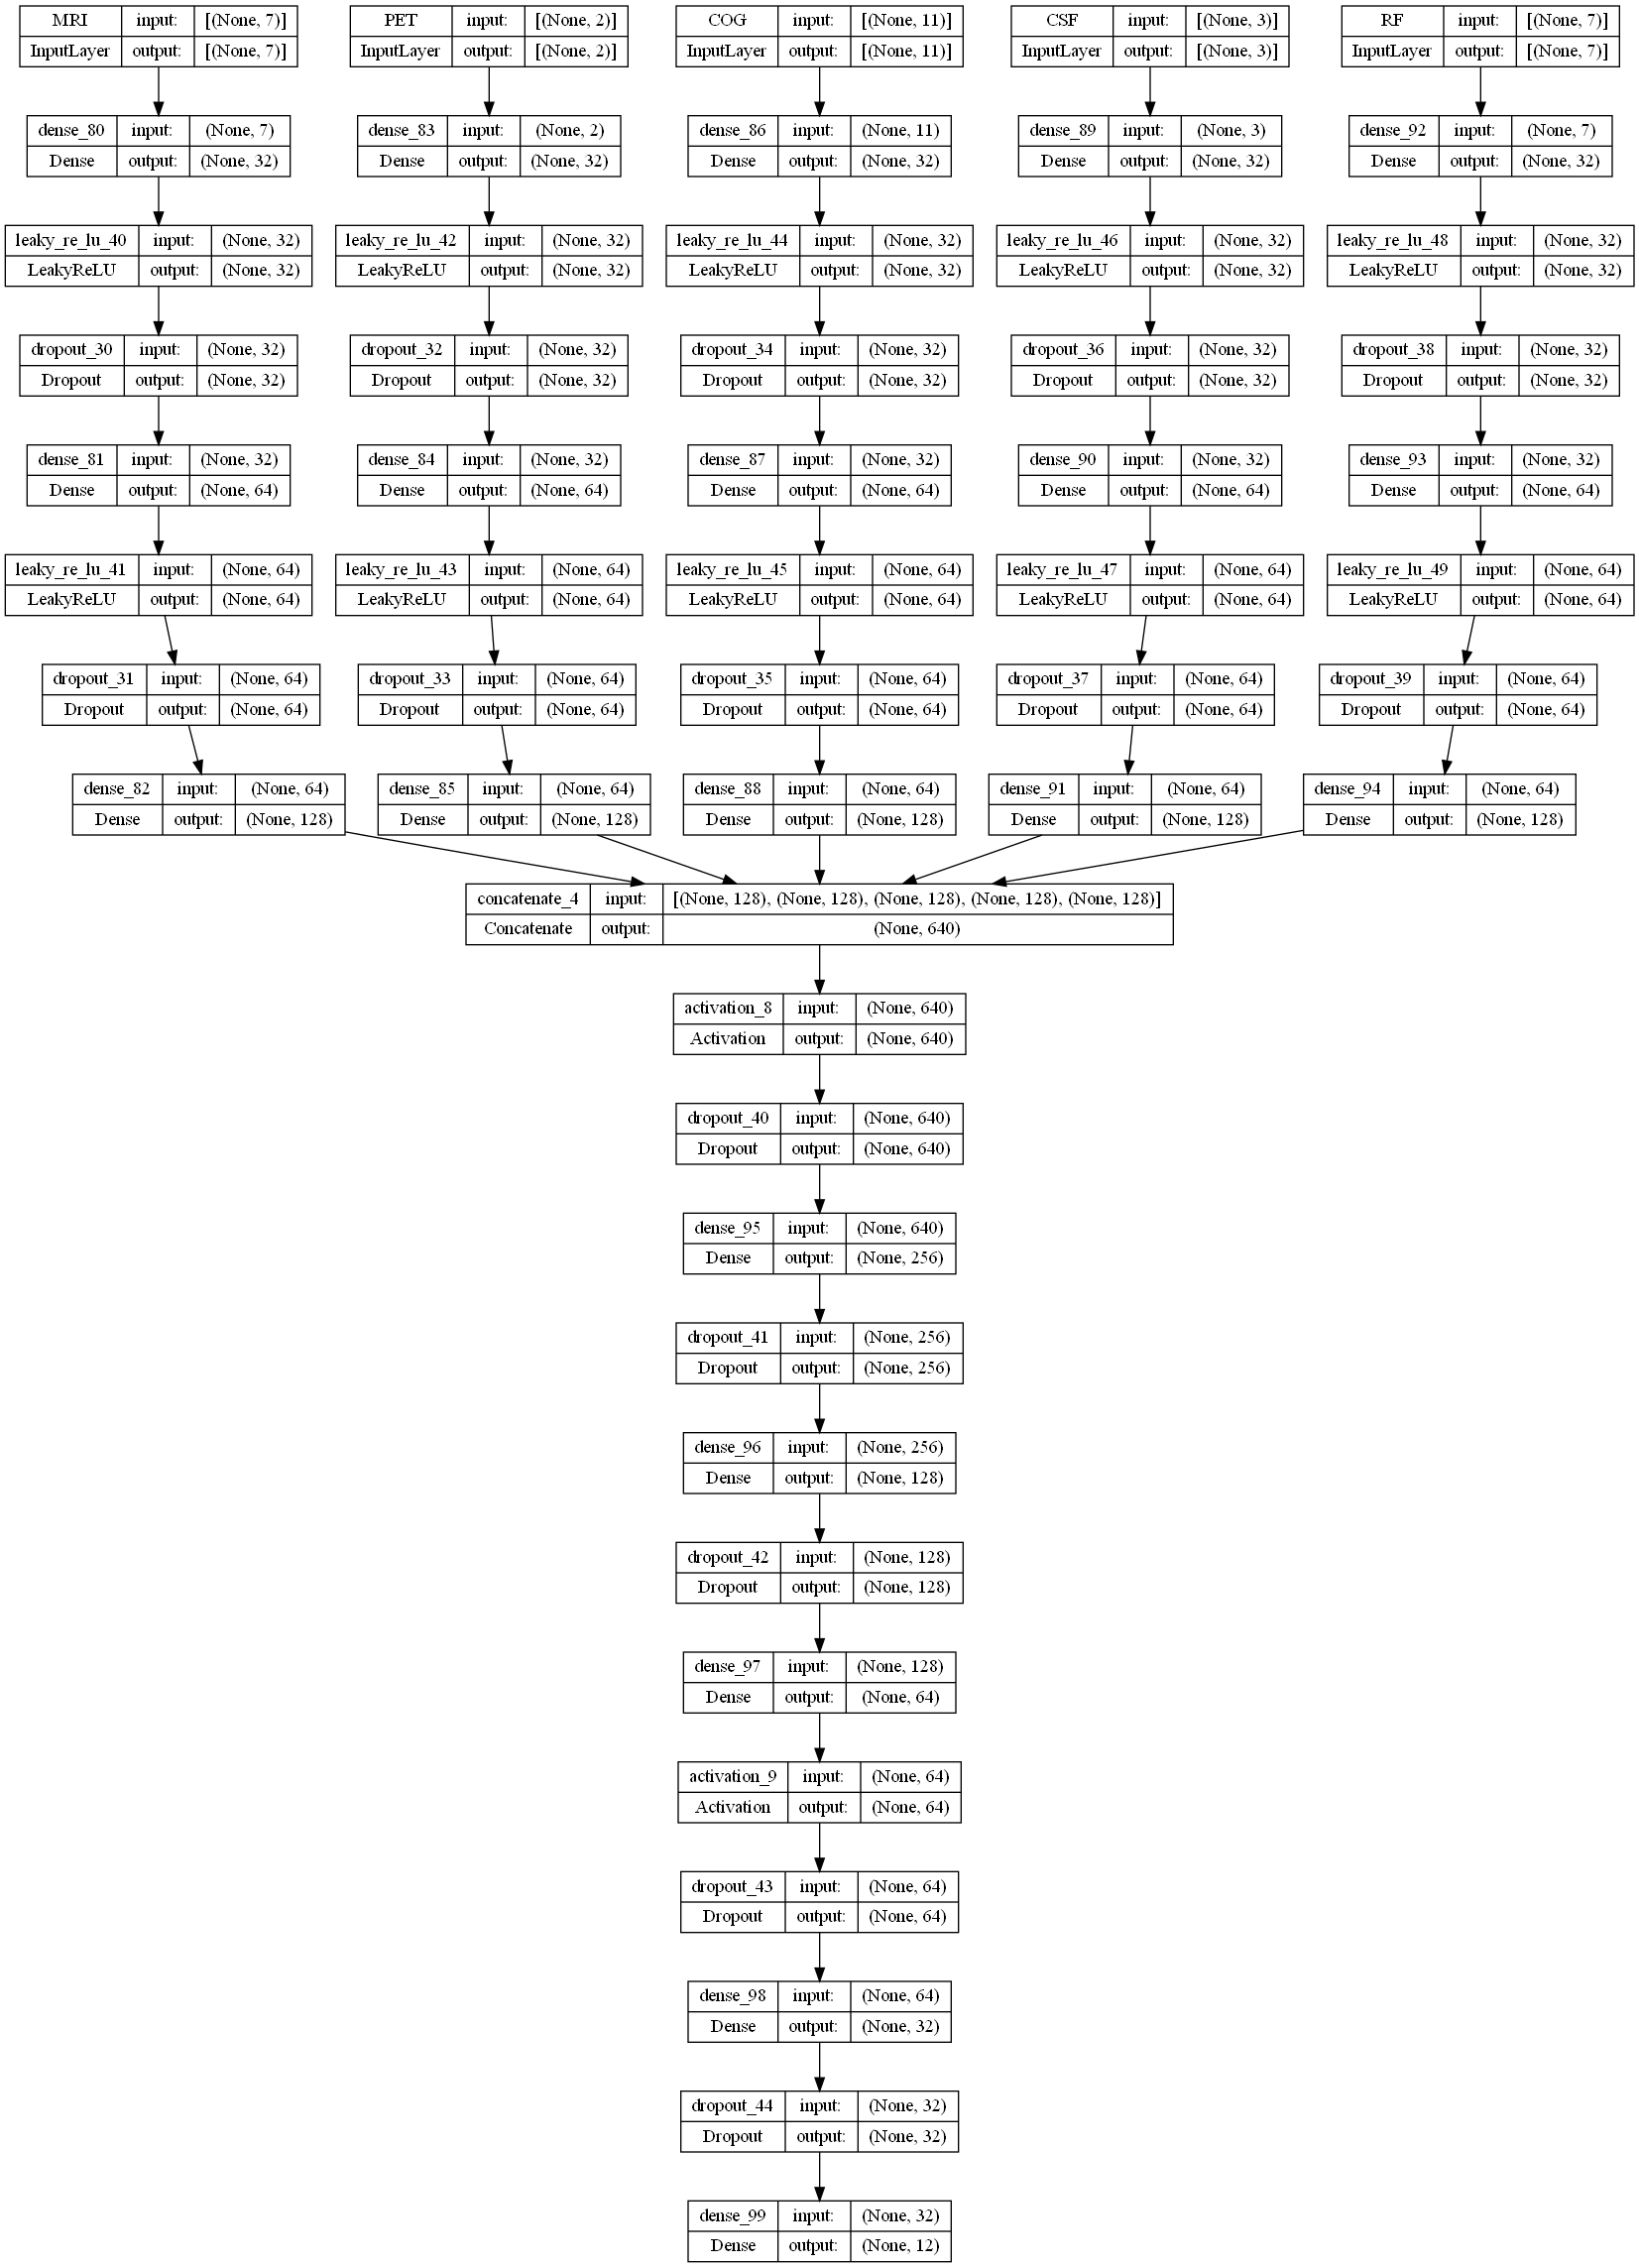

In [61]:
from tensorflow.keras.utils import plot_model

# Save the model architecture as a PNG file
plot_model(model_tensorization, to_file='model_tree.png', show_shapes=True, show_layer_names=True)

In [131]:
import tensorflow as tf
from tensorflow.keras.losses import CategoricalCrossentropy

def grouped_categorical_crossentropy(y_true, y_pred):
    """
    Custom loss function that calculates average categorical cross entropy for groups of outputs.
    Groups: [0-2], [3-5], [6-8], [9-11]
    
    Args:
        y_true: Ground truth values, shape (batch_size, num_classes)
        y_pred: Predicted values, shape (batch_size, num_classes)
        
    Returns:
        Average of categorical cross entropy losses across the groups
    """
    # Initialize categorical cross entropy loss function
    cce = CategoricalCrossentropy(from_logits=False, reduction=tf.keras.losses.Reduction.NONE)
    
    # Define groups of indices
    groups = [(0, 3), (3, 6), (6, 9), (9, 12)]
    
    # Compute CCE loss for each group
    group_losses = []
    for start, end in groups:
        loss = cce(y_true[..., start:end], y_pred[..., start:end])
        group_losses.append(loss)
    
    # Stack losses and compute the mean across groups
    all_losses = tf.stack(group_losses, axis=-1)  # Shape: (batch_size, num_groups)
    mean_loss_per_sample = tf.reduce_mean(all_losses, axis=-1)  # Mean across groups

    # Final mean across the batch
    final_loss = tf.reduce_mean(mean_loss_per_sample)  
    
    return final_loss


In [132]:
import tensorflow as tf

def grouped_categorical_accuracy(y_true, y_pred):
    """
    Computes average categorical accuracy for grouped outputs:
    Groups: [0-2], [3-5], [6-8], [9-11]
    """
    groups = [(0, 3), (3, 6), (6, 9), (9, 12)]
    accuracies = []

    for start, end in groups:
        true_group = y_true[..., start:end]
        pred_group = y_pred[..., start:end]

        # Convert one-hot to class indices
        true_labels = tf.argmax(true_group, axis=-1)
        pred_labels = tf.argmax(pred_group, axis=-1)

        acc = tf.cast(tf.equal(true_labels, pred_labels), tf.float32)
        accuracies.append(acc)

    # Stack group accuracies and compute mean per sample
    all_accuracies = tf.stack(accuracies, axis=-1)  # (batch_size, num_groups)
    mean_accuracy = tf.reduce_mean(all_accuracies, axis=-1)  # Mean per sample

    # Final mean across batch
    return tf.reduce_mean(mean_accuracy)


In [133]:
from sklearn.model_selection import train_test_split
x = np.arange(0, len(X_all[1]),1)
train, test = train_test_split(x, shuffle=True, random_state=7, test_size=0.1)

# move_ids = {4332, 5080, 3386, 4477, 4473, 4229}
move_ids = {4442, 4303, 4202, 5040, 3368, 4446}
# Convert train and test to lists temporarily
train_list = train.tolist()
test_list = test.tolist()

# Move matching IDs
moving = [id for id in train_list if id in move_ids]
train_list = [id for id in train_list if id not in move_ids]
test_list.extend(moving)

# Convert back to NumPy arrays
train = np.array(train_list)
test = np.array(test_list)


Y_train_here_4Net=Y_all_tensors[train]
X_train_here_4Net=[X_all[0][train], X_all[1][train], X_all[2][train], X_all[3][train],X_all[4][train]]
X_train_here_names=X_all_IDs[train]

In [134]:
import time

# model_tensorization.load_weights('best_model_SavedInitialWeights_tensors.weights_new.h5')
model_tensorization.compile(loss=grouped_categorical_crossentropy, optimizer='adam', metrics=[grouped_categorical_accuracy])
# model_tensorization.save_weights('SavedInitialWeights_tensors.weights_new.h5')
callback_1 = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.9, patience=10, min_lr=1e-6, verbose=1)
callback_2 = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=1)

start_time = time.time()
History = model_tensorization.fit(X_train_here_4Net, Y_train_here_4Net, 
validation_split=0.15,  epochs=600, batch_size=64,
    verbose=1 , callbacks=[callback_2]) # , callbacks=[callback_1, callback_2]
elapsed_time = time.time() - start_time
print('----- train elapsed time:', elapsed_time)

Epoch 1/600
68/68 [==============================] - 5s 26ms/step - loss: 0.7281 - grouped_categorical_accuracy: 0.6320 - val_loss: 0.7711 - val_grouped_categorical_accuracy: 0.8352
Epoch 2/600
68/68 [==============================] - 1s 15ms/step - loss: 0.4638 - grouped_categorical_accuracy: 0.7984 - val_loss: 0.5761 - val_grouped_categorical_accuracy: 0.8839
Epoch 3/600
 4/68 [>.............................] - ETA: 1s - loss: 0.4252 - grouped_categorical_accuracy: 0.8232

KeyboardInterrupt: 

In [135]:
import tensorflow as tf
import numpy as np
import time

# Define how many models you want in your ensemble
n_models = 25
ensemble_models = []

# Training loop for each model in the ensemble
for i in range(n_models):
    print(f"\nTraining model {i+1}/{n_models}...")
    
    # Clone a new instance of the base model
    model_tensorization = create_model()
    model_tensorization.compile(loss=grouped_categorical_crossentropy, 
                  optimizer='adam', 
                  metrics=[grouped_categorical_accuracy])
    
    callback_early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=25, restore_best_weights=True, verbose=1
    )
    callback_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.9, patience=10, min_lr=1e-6, verbose=1
    )

    start_time = time.time()
    model_tensorization.fit(
        X_train_here_4Net, Y_train_here_4Net, 
        validation_split=0.15, 
        epochs=600, 
        batch_size=64,
        verbose=1, 
        callbacks=[callback_early_stop, callback_reduce_lr]
    )
    elapsed_time = time.time() - start_time
    print(f'Model {i+1} training time: {elapsed_time:.2f} seconds')
    
    # Save the trained model to the ensemble list
    ensemble_models.append(model_tensorization)



Training model 1/25...
Epoch 1/600
68/68 [==============================] - 5s 28ms/step - loss: 0.7252 - grouped_categorical_accuracy: 0.6447 - val_loss: 0.7576 - val_grouped_categorical_accuracy: 0.8080 - lr: 0.0010
Epoch 2/600
68/68 [==============================] - 1s 14ms/step - loss: 0.4630 - grouped_categorical_accuracy: 0.8094 - val_loss: 0.6063 - val_grouped_categorical_accuracy: 0.8939 - lr: 0.0010
Epoch 3/600
68/68 [==============================] - 1s 16ms/step - loss: 0.3694 - grouped_categorical_accuracy: 0.8582 - val_loss: 0.5489 - val_grouped_categorical_accuracy: 0.8993 - lr: 0.0010
Epoch 4/600
68/68 [==============================] - 1s 20ms/step - loss: 0.3204 - grouped_categorical_accuracy: 0.8847 - val_loss: 0.4632 - val_grouped_categorical_accuracy: 0.9003 - lr: 0.0010
Epoch 5/600
68/68 [==============================] - 1s 17ms/step - loss: 0.2981 - grouped_categorical_accuracy: 0.8905 - val_loss: 0.3894 - val_grouped_categorical_accuracy: 0.9014 - lr: 0.0010
E

In [151]:
import os

# Assuming ensemble_models is a list of Keras models
# and you want to save each model to a specific directory
save_dir = 'saved_models'
os.makedirs(save_dir, exist_ok=True)

for idx, model in enumerate(ensemble_models):
    model_path = os.path.join(save_dir, f'ensemble_model_{idx}.h5')
    model.save(model_path)
    print(f'Model {idx} saved to {model_path}')


Model 0 saved to saved_models\ensemble_model_0.h5
Model 1 saved to saved_models\ensemble_model_1.h5
Model 2 saved to saved_models\ensemble_model_2.h5
Model 3 saved to saved_models\ensemble_model_3.h5
Model 4 saved to saved_models\ensemble_model_4.h5
Model 5 saved to saved_models\ensemble_model_5.h5
Model 6 saved to saved_models\ensemble_model_6.h5
Model 7 saved to saved_models\ensemble_model_7.h5
Model 8 saved to saved_models\ensemble_model_8.h5
Model 9 saved to saved_models\ensemble_model_9.h5
Model 10 saved to saved_models\ensemble_model_10.h5
Model 11 saved to saved_models\ensemble_model_11.h5
Model 12 saved to saved_models\ensemble_model_12.h5
Model 13 saved to saved_models\ensemble_model_13.h5
Model 14 saved to saved_models\ensemble_model_14.h5
Model 15 saved to saved_models\ensemble_model_15.h5
Model 16 saved to saved_models\ensemble_model_16.h5
Model 17 saved to saved_models\ensemble_model_17.h5
Model 18 saved to saved_models\ensemble_model_18.h5
Model 19 saved to saved_models\e

In [223]:
def ensemble_predict_with_uncertainty(models, X_input):
    # Collect all model predictions
    all_preds = np.array([model.predict(X_input) for model in models])  # Shape: (n_models, n_samples, n_classes)
    
    # Mean prediction (ensemble output)
    mean_preds = np.mean(all_preds, axis=0)  # Shape: (n_samples, n_classes)
    
    # Predictive uncertainty: variance across model outputs
    uncertainty = np.var(all_preds, axis=0)  # Shape: (n_samples, n_classes)
    
    return mean_preds, uncertainty


In [219]:
X_test_here_4Net=[X_all[0][test], X_all[1][test], X_all[2][test], X_all[3][test], X_all[4][test]]
Y_test_here_4Net=Y_all_tensors[test]
X_test_here_names=X_all_IDs[test]

In [225]:
# Get predictions and uncertainties on test data
Y_pred_ensemble, Y_uncertainty = ensemble_predict_with_uncertainty(ensemble_models, X_test_here_4Net)

# # For each sample, get the predicted class and uncertainty for that class
# predicted_classes = np.argmax(Y_pred_ensemble, axis=1)
# uncertainty_scores = np.take_along_axis(Y_uncertainty, np.expand_dims(predicted_classes, axis=1), axis=1).squeeze()

# # Print example
# for i in range(5):
#     print(f"Sample {i}: predicted class = {predicted_classes[i]}, uncertainty = {uncertainty_scores[i]:.4f}")


18/18 [==============================] - 1s 19ms/step


In [139]:
Y_pred_ensemble[0]

array([1.8884706e-03, 9.9798036e-01, 1.3118464e-04, 5.1928582e-03,
       9.9218142e-01, 2.6257813e-03, 9.1445241e-03, 9.8421144e-01,
       6.6440296e-03, 3.9916184e-02, 9.2645699e-01, 3.3626862e-02],
      dtype=float32)

In [228]:
Y_uncertainty[0]

array([9.2411929e-06, 9.3137896e-06, 1.4873251e-07, 3.8895629e-05,
       9.1598937e-05, 6.4707419e-05, 1.0474257e-04, 3.9435280e-04,
       3.5405395e-04, 9.6847559e-04, 4.2146267e-03, 4.3490697e-03],
      dtype=float32)

In [227]:
import numpy as np

# Assuming Y_uncertainty is already defined
max_value = np.max(Y_uncertainty)
min_value = np.min(Y_uncertainty)

print("Maximum value:", max_value)
print("Minimum value:", min_value)

Maximum value: 0.14735177
Minimum value: 0.0


In [ ]:
# model_tensorization.save("model_tensorization_for_paper_05-01-2025.h5")

In [129]:
from keras.models import load_model
model_tensorization = load_model('model_tensorization_for_paper_05-01-2025.h5', custom_objects={'grouped_softmax': grouped_softmax, 'grouped_categorical_crossentropy': grouped_categorical_crossentropy, 'grouped_categorical_accuracy': grouped_categorical_accuracy, 'MCDropout': MCDropout})

In [ ]:
results = model_tensorization.evaluate(X_test_here_4Net, Y_test_here_4Net)
print(results)
output=model_tensorization.predict(X_test_here_4Net)

In [98]:
results = model_tensorization.evaluate(X_test_here_4Net, Y_test_here_4Net)
print(results)
output=model_tensorization.predict(X_test_here_4Net)

18/18 [==============================] - 1s 5ms/step - loss: 0.1719 - grouped_categorical_accuracy: 0.9306
[0.17192263901233673, 0.9306344985961914]
18/18 [==============================] - 0s 4ms/step


In [42]:
output.shape

(566, 12)

In [44]:
Y_test_here_4Net.shape

(566, 12)

In [46]:
len(Y_test_here_4Net)

566

In [141]:
y_true = np.reshape(Y_test_here_4Net,(len(Y_test_here_4Net),4,3)).transpose(0, 2, 1)
y_true[0]

array([[0., 0., 0., 0.],
       [1., 1., 1., 0.],
       [0., 0., 0., 1.]])

In [142]:
Y_pred_ensemble = np.round(Y_pred_ensemble, 2)
y_pred = np.reshape(Y_pred_ensemble,(len(Y_pred_ensemble),4,3)).transpose(0, 2, 1)
y_pred[0]

array([[0.  , 0.01, 0.01, 0.04],
       [1.  , 0.99, 0.98, 0.93],
       [0.  , 0.  , 0.01, 0.03]], dtype=float32)

In [143]:
Y_uncertainty = np.round(Y_uncertainty, 2)
y_var = np.reshape(Y_uncertainty,(len(Y_uncertainty),4,3)).transpose(0, 2, 1)
y_var[0]

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]], dtype=float32)

In [144]:
y_true_img = create_image(y_true)
y_true_img[53,:,:,:]


array([[[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.]]])

In [270]:
import numpy as np
import matplotlib.pyplot as plt

def plot_output(img, y, title, var=None):
    if var is None or np.isscalar(var):
        var = np.zeros_like(y)

    plt.imshow(img)
    plt.title(title)

    # Set x-axis ticks and labels
    x_ticks = [0, 1, 2, 3]
    x_labels = ["T0", "T6", "T12", "T24"]
    plt.xticks(x_ticks, x_labels)

    # Set y-axis ticks and labels
    y_ticks = [0, 1, 2]
    y_labels = ["CN", "MCI", "AD"]
    plt.yticks(y_ticks, y_labels)

    plt.ylim(2.5, -1)

    if title == "Predicted":
        plt.axhspan(-1, -0.5, facecolor='gold', zorder=0)
    else:
        plt.axhspan(-1, -0.5, facecolor='gold', hatch='///', edgecolor='black', zorder=0)

    # Grid lines
    for x in range(1, len(x_ticks)):
        plt.axvline(x=x - 0.5, color='silver', linewidth=1)
    plt.axhline(y=0.495, color='gray', linestyle='--', linewidth=0.25)
    plt.axhline(y=1.495, color='gray', linestyle='--', linewidth=0.25)
    plt.axhline(y=-0.495, color='gray', linestyle='--', linewidth=0.25)

    # Show main label values
    for i in range(y.shape[1]):       # Time (x-axis)
        for j in range(y.shape[0]):   # Class (y-axis)
            label = y[j, i]
            if label is not None and label > 0:
                plt.text(i, j, f"{label:.2f}", color='white', fontsize=7, ha='center', va='center')

    # Safely reshape var to match (classes, timepoints)
    try:
        reshaped_var = var.reshape((3, -1))  # Assuming 3 classes
        for i in range(reshaped_var.shape[1]):  # Iterate over timepoints
            max_uncertainty = np.max(reshaped_var[:, i])
            if title == "Predicted":
                plt.text(i, -0.75, f"{np.exp(-5*max_uncertainty):.2f}", color='black', fontsize=7, ha='center', va='center')
    except:
        print("Warning: Could not reshape or interpret 'var' for uncertainty strip.")

    # Set plot limits
    

    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_edgecolor('silver')
        spine.set_linewidth(1)


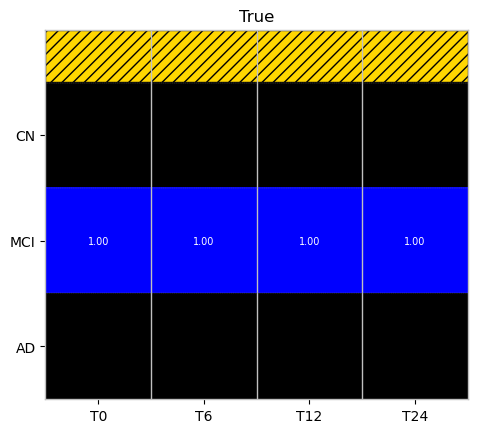

In [271]:
plot_output(y_true_img[15, :, :, :],y_true[15], "True" )

In [255]:
y_pred_img = create_image(y_pred)
y_pred_img[0,:,:,:]


array([[[0.        , 0.        , 0.        ],
        [0.        , 0.01      , 0.        ],
        [0.        , 0.01      , 0.        ],
        [0.        , 0.04      , 0.        ]],

       [[0.        , 0.        , 1.        ],
        [0.        , 0.        , 0.99000001],
        [0.        , 0.        , 0.98000002],
        [0.        , 0.        , 0.93000001]],

       [[0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.01      , 0.        , 0.        ],
        [0.03      , 0.        , 0.        ]]])

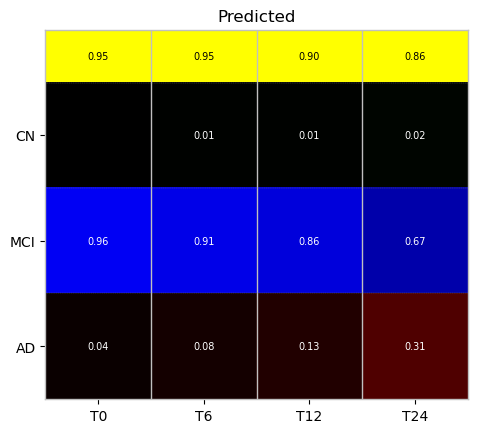

In [265]:
plot_output(y_pred_img[15,:,:,:],y_pred[15], "Predicted", y_var[15])

In [157]:
X_test_here_names

array([4289, 2322, 3049, 1272, 2022, 3853, 4953,  195,  724, 1896,  346,
       4828, 1788, 3533, 2017, 4682,  957, 1700, 2265, 2589, 2749, 4390,
        408,   84, 3351, 3546, 1742, 3127,  664, 1422, 4160,   57, 2377,
       2845, 4834, 5265,   55, 1858, 2168, 5237, 2040, 3327, 4780, 3499,
        666, 2792,  162, 4835, 3690, 3236, 3833, 1060, 5200, 5312, 2878,
       2800, 4762,  247, 2538, 4216, 2210, 4092, 4116, 2316, 1058, 1499,
       1972, 2831,  290,  116, 3873,  434, 4905, 3880, 3644, 3424, 2651,
       5456, 4716, 2452,  474, 1789, 1537, 4635, 3672, 5156, 3709,  150,
       5104,  758, 5044, 2497,  360,  736, 4108, 2605, 4802, 1210, 3896,
       1451,  826, 4469, 2029, 2254, 5235, 2451, 2300, 1525, 3022,  906,
       3547, 1351, 1460, 2587, 5267, 1282, 1137, 4935, 3737, 2745, 4678,
       2828, 1283, 4640,  733, 4943, 3904, 3290, 2977, 5060, 4880, 2407,
        988, 5144, 1885, 4539, 4741, 1687, 5574, 3434,  894, 3352, 3367,
       3003, 2744, 3431,  306, 5345, 1011,  742,  7

In [158]:
X_test_here_names[406]

1336

In [ ]:
AllDataset.iloc[4333]

ID               4334
RID              4357
PTID       006_S_4357
VISCODE            48
SITE                6
              ...    
DX6                CN
12            4357m60
DX12               CN
24            4357m72
DX24               CN
Name: 4334, Length: 69, dtype: object

In [ ]:
AllDataset.iloc[X_test_here_names[5]]["ID"]

3854

In [62]:
y_true_img[570,:,:,:]

IndexError: index 570 is out of bounds for axis 0 with size 566

In [63]:
y_pred_img[570, :, :, :]

IndexError: index 570 is out of bounds for axis 0 with size 566

In [69]:
output[11]

array([0.  , 0.53, 0.47, 0.  , 0.41, 0.59, 0.  , 0.28, 0.72, 0.  , 0.12,
       0.88], dtype=float32)

In [70]:
X_test_here_names[11]

4828

C:\Users\14792\AppData\Local\Temp\ipykernel_21100\2518297497.py:16: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


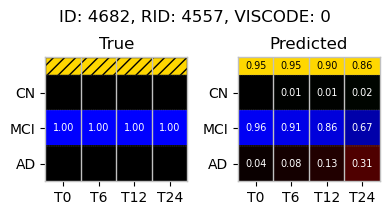

In [272]:
index = 15
fig, axes = plt.subplots(1, 2, figsize=(4, 2))
id = X_test_here_names[index]
rid = AllDataset.loc[AllDataset['ID'] == X_test_here_names[index], 'RID'].values[0]
t_period = AllDataset.loc[AllDataset['ID'] == X_test_here_names[index], 'VISCODE'].values[0]
fig.suptitle(f"ID: {id}, RID: {rid}, VISCODE: {t_period}")

plt.sca(axes[0])
plot_output(y_true_img[index, :, :, :], y_true[index], "True")

plt.sca(axes[1])
plot_output(y_pred_img[index, :, :, :], y_pred[index], "Predicted", y_var[index])

fig.tight_layout()  # reserve space for suptitle
fig.savefig(f"output_{id}.png", dpi=300, bbox_inches='tight')
fig.show()

In [196]:
Y_test_here_4Net[570]

IndexError: index 570 is out of bounds for axis 0 with size 566

In [95]:
len(X_test_here_names)

571

In [96]:
AllDataset.head()

,ID,RID,PTID,VISCODE,SITE,COLPROT,ORIGPROT,EXAMDATE,DX_bl,AGE,...,ICV,Unnamed: 60,Unnamed: 61,DX,6,DX6,12,DX12,24,DX24
ID,,,,,,,,,,,,,,,,,,,,,
1,1,2,011_S_0002,0,11,ADNI1,ADNI1,38603,CN,74.3000,...,1984660.0000,0,2m0,CN,2m6,CN,2m12,CN,2m24,CN
2,2,2,011_S_0002,6,11,ADNI1,ADNI1,38782,CN,74.8000,...,1516962.1113,6,2m6,CN,2m12,CN,2m18,CN,2m30,CN
3,3,2,011_S_0002,36,11,ADNI1,ADNI1,39687,CN,77.3000,...,1516962.1113,36,2m36,CN,2m42,CN,2m48,CN,2m60,CN
4,4,2,011_S_0002,60,11,ADNIGO,ADNI1,40443,CN,79.3000,...,1516962.1113,60,2m60,CN,2m66,CN,2m72,CN,2m84,MCI
5,5,2,011_S_0002,72,11,ADNI2,ADNI1,40805,CN,80.3000,...,1516962.1113,72,2m72,CN,2m78,CN,2m84,CN,2m96,CN


In [97]:
AllDataset.loc[AllDataset['ID'] == X_test_here_names[50], 'VISCODE']

ID
1210    0
Name: VISCODE, dtype: int64

In [273]:
for index in range(len(X_test_here_names)):
    fig, axes = plt.subplots(1, 2, figsize=(4,2))
    id = X_test_here_names[index]
    rid = AllDataset.loc[AllDataset['ID'] == X_test_here_names[index], 'RID'].values[0]
    t_period = AllDataset.loc[AllDataset['ID'] == X_test_here_names[index], 'VISCODE'].values[0]
    fig.suptitle(f"ID: {id}, RID: {rid}, VISCODE: {t_period}")

    plt.sca(axes[0])
    plot_output(y_true_img[index, :, :, :], y_true[index], "True")

    plt.sca(axes[1])
    plot_output(y_pred_img[index, :, :, :], y_pred[index], "Predicted", y_var[index])
    
    fig.tight_layout()  # reserve space for suptitle
    fig.savefig(f"test_images_imputed_with_ensemble/{rid}_{t_period}.jpg", format='jpg', dpi=300, bbox_inches='tight')
    plt.close(fig)


In [115]:
a = np.array([[[0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]])

aa = np.array([[1., 1., 1., 1.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

b = np.array([[[0., 0., 0.],
            [0., 0., 0.],
            [0., 0., 0.],
            [0., 0., 0.]],

           [[0., 0., 1.],
            [0., 0., 1.],
            [0., 0., 1.],
            [0., 0., 1.]],

           [[0., 0., 0.],
            [0., 0., 0.],
            [0., 0., 0.],
            [0., 0., 0.]]])

bb = np.array([[0., 0., 0., 0.],
               [1., 1., 1., 1.],
                [0., 0., 0., 0.]])


c = np.array([[[0., 0., 0.],
            [0., 0., 0.],
            [0., 0., 0.],
            [0., 0., 0.]],

           [[0., 0., 0.],
            [0., 0., 0.],
            [0., 0., 0.],
            [0., 0., 0.]],

           [[1., 0., 0.],
            [1., 0., 0.],
            [1., 0., 0.],
            [1., 0., 0.]]])

cc = np.array([[0., 0., 0., 0.],
                [0., 0., 0., 0.],
                [1., 1., 1., 1.],])

d = np.array([[[0., 1., 0.],
        [0., .75, 0.],
        [0., .48, 0.],
        [0., .05, 0.]],

       [[0., 0., 0.],
        [0., 0., .25],
        [0., 0., .52],
        [0., 0., .95]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]])

dd = np.array([[1., .75, .48, .05],
               [0., 0.25, .52, .95],
                [0., 0., 0., 0.],])

e = np.array([[[0., 0., 0.],
            [0., 0., 0.],
            [0., 0., 0.],
            [0., 0., 0.]],

           [[0., 0., 1.],
            [0., 0., 0.9],
            [0., 0., 0.73],
            [0., 0., 0.55]],

           [[0., 0., 0.],
            [.1, 0., 0.],
            [.27, 0., 0.],
            [.45, 0., 0.]]])

ee = np.array([[0, 0 , 0., 0.],
               [1., 0.9, .73, .55],
                [0., 0.1, 0.27, .45],])


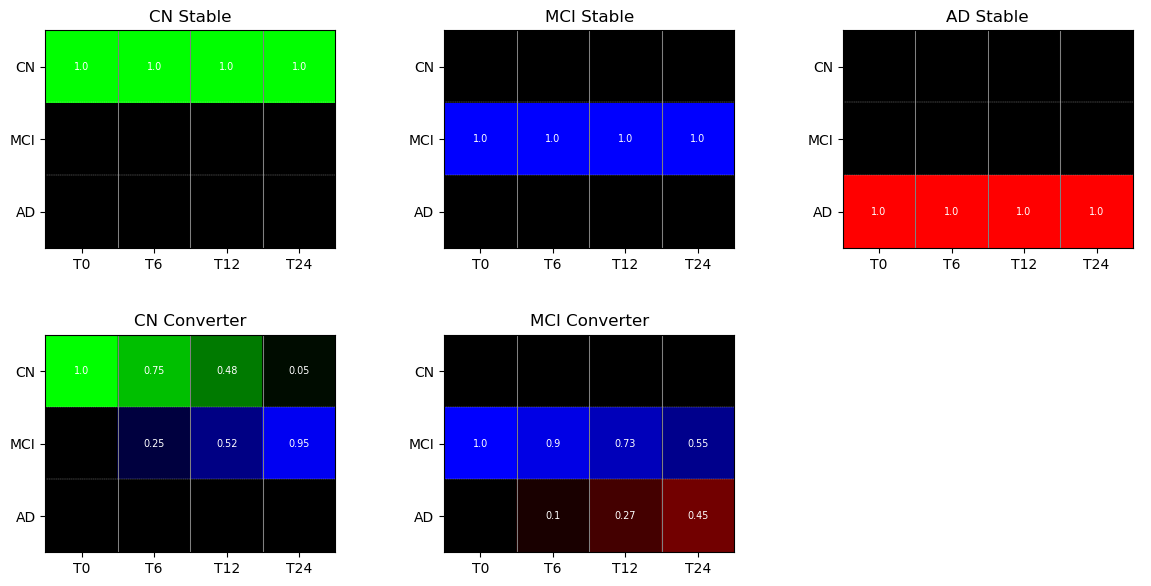

In [116]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

# First row
plt.sca(axes[0,0])
plot_output(a, aa, "CN Stable")

plt.sca(axes[0,1])
plot_output(b, bb, "MCI Stable")

plt.sca(axes[0,2])
plot_output(c, cc, "AD Stable")

# Second row
plt.sca(axes[1,0])
plot_output(d, dd, "CN Converter")

plt.sca(axes[1,1])
plot_output(e, ee, "MCI Converter")

# Hide unused subplot
axes[1,2].axis('off')

# Improve spacing
plt.subplots_adjust(
    left=0.05,    # space from left edge
    right=0.97,   # space from right edge
    top=0.95,     # space from top
    bottom=0.08,  # space from bottom
    wspace=0.3,   # width space between subplots
    hspace=0.4    # height space between subplots
)

plt.show()
